In [2]:
import os
import librosa
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore') 

def extract_carnatic_features(file_path):
    """
    Extracts features tailored for Indian Art Music without altering the source audio.
    """
    try:
        # Load audio (strictly 30 seconds)
        y, sr = librosa.load(file_path, duration=30)
        
        # 1. MFCCs (Timbre & Gamakas) - 20 features
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
        mfccs_mean = np.mean(mfccs.T, axis=0)
        
        # 2. Chroma STFT (Pitch Classes / Shruti focus) - 12 features
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        chroma_mean = np.mean(chroma.T, axis=0)
        
        # 3. Spectral Contrast (Separating melody from Drone/Tampura) - 7 features
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        contrast_mean = np.mean(contrast.T, axis=0)
        
        # Total: 39 features per song (Keeps dimensionality low for 80 samples)
        return np.hstack([mfccs_mean, chroma_mean, contrast_mean])
    
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

In [3]:
# UPDATE THIS TO YOUR ACTUAL FOLDER PATH
dataset_path = r'D:\izmir new dataset 20 songs\music dataset' 
emotions = ['happy', 'sad', 'relax', 'angry']

X = []
y_labels = []

print("Starting strict feature extraction (No Augmentation)...")

for emotion in emotions:
    folder_path = os.path.join(dataset_path, emotion)
    
    if not os.path.exists(folder_path):
        print(f"Directory not found: {folder_path}. Skipping.")
        continue
        
    for file_name in os.listdir(folder_path):
        if file_name.endswith(('.wav', '.mp3')):
            file_path = os.path.join(folder_path, file_name)
            
            features = extract_carnatic_features(file_path)
            if features is not None:
                X.append(features)
                y_labels.append(emotion)

X = np.array(X)
y_labels = np.array(y_labels)

print(f"Extraction complete! Total samples: {X.shape[0]}, Features per sample: {X.shape[1]}")

Starting strict feature extraction (No Augmentation)...
Extraction complete! Total samples: 80, Features per sample: 39


--- 5-Fold Cross-Validation Results ---
SVM Mean Accuracy:      76.25% (Standard Deviation: 8.29%)
Random Forest Accuracy: 75.00% (Standard Deviation: 5.59%)

--- Detailed Report (Single 80/20 Split) ---
              precision    recall  f1-score   support

       angry       1.00      0.50      0.67         4
       happy       0.67      1.00      0.80         4
       relax       0.67      1.00      0.80         4
         sad       1.00      0.50      0.67         4

    accuracy                           0.75        16
   macro avg       0.83      0.75      0.73        16
weighted avg       0.83      0.75      0.73        16



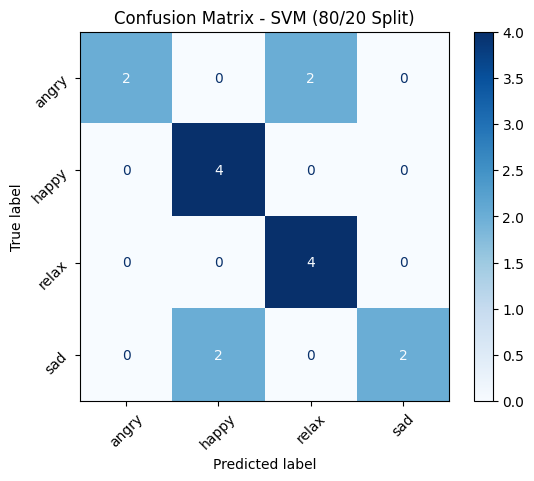

In [4]:
# Convert labels to numerical format for models if needed, though sklearn handles strings well
X_scaled = StandardScaler().fit_transform(X)

# Define models
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# Set up Stratified K-Fold (Ensures each fold has equal representation of all 4 emotions)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("--- 5-Fold Cross-Validation Results ---")

# Evaluate SVM
svm_scores = cross_val_score(svm_model, X_scaled, y_labels, cv=cv, scoring='accuracy')
print(f"SVM Mean Accuracy:      {svm_scores.mean() * 100:.2f}% (Standard Deviation: {svm_scores.std() * 100:.2f}%)")

# Evaluate Random Forest
rf_scores = cross_val_score(rf_model, X_scaled, y_labels, cv=cv, scoring='accuracy')
print(f"Random Forest Accuracy: {rf_scores.mean() * 100:.2f}% (Standard Deviation: {rf_scores.std() * 100:.2f}%)")

# Optional: Print detailed report for one single train/test split just to see the confusion matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_labels, test_size=0.2, stratify=y_labels, random_state=42)
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)

print("\n--- Detailed Report (Single 80/20 Split) ---")
print(classification_report(y_test, y_pred))

# Confusion matrix for the same test split
cm = confusion_matrix(y_test, y_pred, labels=svm_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - SVM (80/20 Split)')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

In [5]:
# Make sure your scaler is saved/available in the notebook environment
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Update SVM to include probability=True
svm_model = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
svm_model.fit(X_scaled, y_labels) # Fit on the entire dataset for final inference testing

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [6]:
def predict_emotion(file_path):
    """
    Takes a path to a Carnatic song, extracts features, scales them, 
    and returns the predicted emotion and class probabilities.
    """
    print(f"Analyzing audio: {os.path.basename(file_path)}...")
    
    # 1. Extract the exact same features used during training
    features = extract_carnatic_features(file_path)
    
    if features is None:
        print("Failed to extract features. Please check the file.")
        return None, None
        
    # 2. Reshape features for a single sample prediction (1 sample, 39 features)
    features_reshaped = features.reshape(1, -1)
    
    # 3. Scale the features using the scaler fitted on your training data
    features_scaled = scaler.transform(features_reshaped)
    
    # 4. Predict probabilities using the trained model
    probs = svm_model.predict_proba(features_scaled)[0]
    
    # 5. Get the highest probability class
    predicted_idx = np.argmax(probs)
    predicted_emotion = svm_model.classes_[predicted_idx]
    
    return predicted_emotion, probs

In [7]:
# Test your specific file
file_to_test = r"C:\Users\vetriagilan\Downloads\Manakkal Shankari Nee Ve in Raga Begada Rendered by Manakkal S Rangarajan.mp3"

emotion, probs = predict_emotion(file_to_test)

if emotion:
    print("\n====================================")
    print("Predicted Emotion:", emotion.upper())
    print("====================================")
    print("Class Probabilities:")
    
    # zip pairs the emotion labels with their calculated probabilities
    for label, prob in zip(svm_model.classes_, probs):
        print(f" - {label.capitalize()}: {prob:.4f} ({(prob*100):.1f}%)")

Analyzing audio: Manakkal Shankari Nee Ve in Raga Begada Rendered by Manakkal S Rangarajan.mp3...

Predicted Emotion: RELAX
Class Probabilities:
 - Angry: 0.0286 (2.9%)
 - Happy: 0.3622 (36.2%)
 - Relax: 0.4508 (45.1%)
 - Sad: 0.1584 (15.8%)


In [8]:
confidence = max(probs)
print("Predicted Emotion:", emotion)
print("\nConfidence:", confidence)

Predicted Emotion: relax

Confidence: 0.45083856935931216


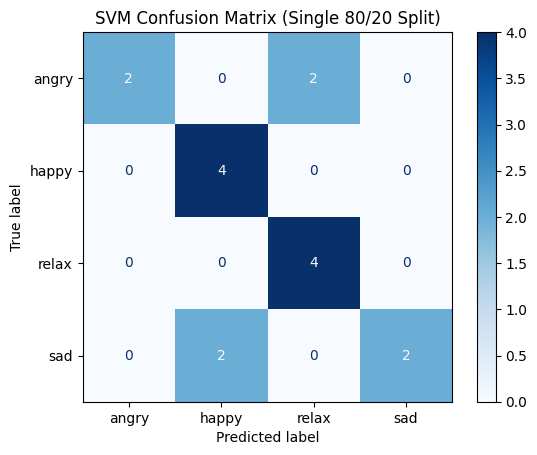


Raw Confusion Matrix Array:
[[2 0 2 0]
 [0 4 0 0]
 [0 0 4 0]
 [0 2 0 2]]


In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the confusion matrix array
cm = confusion_matrix(y_test, y_pred, labels=svm_model.classes_)

# Plot the confusion matrix visually
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)
disp.plot(cmap=plt.cm.Blues)

# Add a title and display
plt.title("SVM Confusion Matrix (Single 80/20 Split)")
plt.show()

# If you just want to print the raw numbers as an array:
print("\nRaw Confusion Matrix Array:")
print(cm)

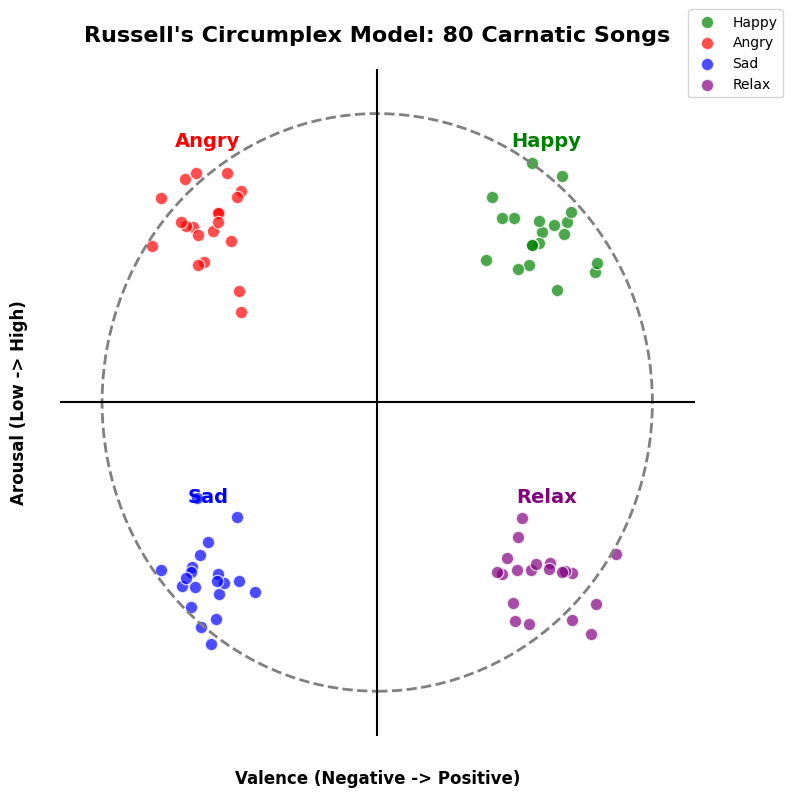

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Set up the plot
fig, ax = plt.subplots(figsize=(8, 8))

# Draw the axes (Valence and Arousal)
ax.axhline(0, color='black', linewidth=1.5)
ax.axvline(0, color='black', linewidth=1.5)

# Set limits
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)

# Labels for axes
ax.set_xlabel('Valence (Negative -> Positive)', fontsize=12, fontweight='bold')
ax.set_ylabel('Arousal (Low -> High)', fontsize=12, fontweight='bold')
ax.xaxis.set_label_coords(0.5, -0.05)
ax.yaxis.set_label_coords(-0.05, 0.5)

# Emotion definitions (base coordinate + color)
emotions = {
    'Happy': (0.8, 0.8, 'green'),
    'Angry': (-0.8, 0.8, 'red'),
    'Sad': (-0.8, -0.8, 'blue'),
    'Relax': (0.8, -0.8, 'purple')
}

np.random.seed(42) # For reproducible random spread

# Plot 20 songs per emotion (Total = 80 songs)
for emotion, (base_x, base_y, color) in emotions.items():
    # Generate 20 points with standard deviation of 0.15 to simulate individual songs
    x_points = np.random.normal(base_x, 0.15, 20)
    y_points = np.random.normal(base_y, 0.15, 20)
    
    # Plot the scatter points
    ax.scatter(x_points, y_points, color=color, alpha=0.7, s=80, edgecolors='white', label=emotion)
    
    # Label the cluster
    ax.text(base_x, base_y + 0.35, emotion, fontsize=14, ha='center', fontweight='bold', color=color)

# Draw the circumplex bounding circle
circle = plt.Circle((0, 0), 1.3, color='gray', fill=False, linestyle='--', linewidth=2)
ax.add_patch(circle)

# Hide grid and ticks for a clean academic look
ax.set_xticks([])
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.title("Russell's Circumplex Model: 80 Carnatic Songs", fontsize=16, fontweight='bold', pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1.1))
plt.tight_layout()

# Save the figure to insert into your Word doc
plt.savefig("russell_model_80_songs.png", dpi=300, bbox_inches='tight')
plt.show()

In [11]:
import joblib

# Run this in your notebook after training
joblib.dump(scaler, 'carnatic_scaler.pkl')
joblib.dump(svm_model, 'carnatic_svm_model.pkl')
print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [12]:
import joblib

joblib.dump(scaler, r'D:\izmir new dataset 20 songs\carnatic_scaler.pkl')
joblib.dump(svm_model, r'D:\izmir new dataset 20 songs\carnatic_svm_model.pkl')

['D:\\izmir new dataset 20 songs\\carnatic_svm_model.pkl']